---
title: "✅ LSE DS202W 2025/2026: Week 10 - Student Solutions"
author: "MY NAME (MY CANDIDATE NUMBER)"
date: 09 March 2026
---

# 📚 Preparation: Loading packages and data

## ⚙️ Setup


> ⚠️ **Windows Users:** Some libraries in this lab, particularly `bertopic` and `sentence-transformers`, may **stall or hang** when imported in standard Jupyter Notebook or VSCode. If you experience this, we recommend opening and running this file in **JupyterLab** instead (`jupyter lab` from your terminal). JupyterLab handles multiprocessing-based imports more reliably on Windows.

**Install missing libraries:**

First, install all required packages using conda:

```bash
# Core data science libraries
conda install -c conda-forge pandas numpy matplotlib seaborn

# Text processing and NLP
conda install -c conda-forge wordcloud textblob nltk spacy

# Machine learning libraries
conda install -c conda-forge scikit-learn lightgbm xgboost shap

# Modern NLP and topic modeling
conda install -c conda-forge bertopic sentence-transformers

# Visualization
conda install -c conda-forge plotly

# Install spaCy English model
python -m spacy download en_core_web_sm
```

> 💡 **Prefer conda over pip where possible** — `conda-forge` builds are compiled against consistent native libraries and tend to avoid the DLL/dependency conflicts that can cause `bertopic` and `sentence-transformers` to stall on Windows. If a package is not available on `conda-forge`, fall back to `pip install <package>` afterwards.

**Import required libraries:**

In [1]:
# Core data manipulation and analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Text processing and NLP
import re
import string
from wordcloud import WordCloud
from textblob import TextBlob
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import spacy

# Machine learning and model evaluation
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    f1_score
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier

# Model interpretation and explainability
import shap

# Modern topic modeling
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

# Advanced visualization
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Download necessary NLTK data (run once)
print("Downloading NLTK data...")
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
print("NLTK downloads complete!")

# Load spaCy model (make sure it's installed: python -m spacy download en_core_web_sm)
try:
    nlp = spacy.load("en_core_web_sm")
    print("spaCy model loaded successfully!")
except OSError:
    print("⚠️  Please install spaCy English model: python -m spacy download en_core_web_sm")
    nlp = None

# Set plotting style
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("All libraries imported successfully! 🎉")

NLTK downloads complete!
spaCy model loaded successfully!
All libraries imported successfully! 🎉


# A new data set: European Central Bank (ECB) statements (5 minutes)

In [ ]:
ecb_data = pd.read_csv("data/ECB_prelabelled_sent.txt")

# Convert sentiment to categorical labels
ecb_data['sentiment_label'] = ecb_data['sentiment'].map({1: 'Positive', 0: 'Negative'})

# Remove any missing values
ecb_data = ecb_data.dropna().reset_index(drop=True)

print(f"Dataset shape: {ecb_data.shape}")
print(f"Columns: {list(ecb_data.columns)}")
print(f"Sentiment distribution:\n{ecb_data['sentiment_label'].value_counts()}")
ecb_data.head()

Dataset shape: (2563, 3)
Columns: ['text', 'sentiment', 'sentiment_label']
Sentiment distribution:
sentiment_label
Negative    1609
Positive     954
Name: count, dtype: int64


,text,sentiment,sentiment_label
0,target2 is seen as a tool to promote the furth...,1,Positive
1,the slovak republic for example is now home to...,1,Positive
2,the earlier this happens the earlier economic ...,1,Positive
3,the bank has made essential contributions in k...,1,Positive
4,moreover the economic size and welldeveloped f...,1,Positive


Today, we will be looking at a data set of statements from the European Central Bank.

-   `text`: The ECB statement text.
-   `sentiment`: Numeric sentiment label (1 = positive, 0 = negative).
-   `sentiment_label`: Categorical sentiment label (Positive/Negative).

The column we are going to analyze in detail is `text` which contains ECB statements that we can analyze for sentiment and topics.

# Enter Natural Language Processing with Python! (25 minutes)

Python offers excellent libraries for natural language processing. We'll use a combination of `nltk`, `spacy`, and `scikit-learn` for text preprocessing and feature extraction.

## Text Preprocessing

First, let's create a comprehensive preprocessing function adapted for financial/economic text:

In [3]:
def preprocess_text(text, remove_stopwords=True, lemmatize=True):
    """
    Comprehensive text preprocessing function for ECB statements
    """
    if pd.isna(text):
        return ""
    
    # Convert to lowercase
    text = str(text).lower()
    
    # Remove URLs, mentions, hashtags
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'@\w+|#\w+', '', text)
    
    # Remove punctuation but keep decimal points for financial data
    text = re.sub(r'[^\w\s\.]', '', text)
    
    # Remove extra whitespace
    text = ' '.join(text.split())
    
    if remove_stopwords:
        # Remove stopwords
        stop_words = set(stopwords.words('english'))
        # Add custom stopwords for ECB statements
        custom_stopwords = {'said', 'one', 'would', 'also', 'get', 'go', 'see', 'well', 'may', 'could'}
        stop_words.update(custom_stopwords)
        
        tokens = word_tokenize(text)
        tokens = [token for token in tokens if token not in stop_words and len(token) > 2]
        text = ' '.join(tokens)
    
    if lemmatize and nlp is not None:
        # Lemmatization using spaCy
        doc = nlp(text)
        text = ' '.join([token.lemma_ for token in doc if not token.is_stop and len(token.text) > 2])
    
    return text

# Apply preprocessing
ecb_data['text_clean'] = ecb_data['text'].apply(preprocess_text)

# Remove empty texts after cleaning
ecb_data = ecb_data[ecb_data['text_clean'].str.len() > 0].reset_index(drop=True)

print(f"Dataset shape after cleaning: {ecb_data.shape}")

Dataset shape after cleaning: (2563, 4)


**✅ Output note: text preprocessing:**

The output `Dataset shape after cleaning: (2563, 4)` confirms that:

- No documents were lost during preprocessing — all 2,563 ECB statements survived the cleaning pipeline.
- A new column `text_clean` has been added (hence 4 columns vs the original 3).

This is a good sanity check: if a large number of rows had been dropped here it would suggest the preprocessing was too aggressive (e.g. stripping content from very short statements). It also confirms that lemmatization and stopword removal do not cause empty-string outputs for this corpus.

> ⚠️ **Note on `remove_stopwords=False, lemmatize=False`:** If you pass these flags when calling `preprocess_text()`, the word cloud might look different. Function words like *the*, *of*, *in*, and *will* are likely to dominate, obscuring the economically meaningful terms. However, you may notice the **overall shape of the cloud changes only modestly** for the most prominent words (*euro*, *area*, *market*, *growth*). This is because the `CountVectorizer` used in the next step applies its own `min_df`, `max_df`, and token-pattern filters so many high-frequency stopwords are already suppressed at the vectorisation stage regardless of what the preprocessing function does. The preprocessing and vectorisation steps are **complementary, not redundant**: preprocessing removes noise before counting; `CountVectorizer` then controls the vocabulary scope.

## Creating Document-Term Matrix

We'll use scikit-learn's `CountVectorizer` to create our document-term matrix that:

1. Limits to the top **1,000 features** (`max_features=1000`)
2. Requires a minimum **document frequency of 5** (`min_df=5`) — ignores very rare terms
3. Removes terms appearing in **more than 95%** of documents (`max_df=0.95`) — removes near-universal words
4. Includes **unigrams and bigrams** (`ngram_range=(1, 2)`) — captures two-word financial phrases like *financial market*
5. Keeps only **words with at least 3 characters** (`token_pattern=r'\b[a-zA-Z]{3,}\b'`)

In [4]:
# Create vectorizer with parameters suitable for financial text
vectorizer = CountVectorizer(
    max_features=1000,  # Limit to top 1000 features
    min_df=5,           # Minimum document frequency
    max_df=0.95,        # Remove terms that appear in >95% of documents
    ngram_range=(1, 2), # Include bigrams for financial terms
    token_pattern=r'\b[a-zA-Z]{3,}\b'  # Words with at least 3 characters
)

# Fit and transform the cleaned text
doc_term_matrix = vectorizer.fit_transform(ecb_data['text_clean'])
feature_names = vectorizer.get_feature_names_out()

print(f"Document-term matrix shape: {doc_term_matrix.shape}")
print(f"Number of features: {len(feature_names)}")
print(f"Sample features: {feature_names[:20]}")

Document-term matrix shape: (2563, 1000)
Number of features: 1000
Sample features: ['ability' 'able' 'accelerate' 'access' 'accompany' 'account'
 'account deficit' 'accountability' 'accumulation' 'achieve' 'act'
 'action' 'activity' 'actually' 'add' 'addition' 'additional' 'address'
 'adjust' 'adjustment']


**✅ Output note: Document-Term Matrix:**

The output confirms the matrix has shape **(2563 documents × 1000 features)**, exactly as configured.

A few things worth noting in the sample features:

- Terms are sorted **alphabetically** by default — this is just the display order, not ranked by frequency.
- `'account deficit'` appearing in the sample confirms that **bigrams are working**; two-word phrases relevant to ECB discourse (e.g. *current account deficit*, *financial market*, *monetary policy*) are being captured alongside single words.
- All sample terms are at least 3 characters long, confirming the `token_pattern` filter is active.

> 📦 **What is a `CountVectorizer`?**
> 
> `CountVectorizer` converts a collection of text documents into a **document-term matrix (DTM)** — > a numerical table where each **row** is a document and each **column** is a vocabulary term. > Each cell contains the **count** of how many times that term appears in that document.
> 
> This transforms unstructured text into a structured numerical format that machine learning models can work with. > The result is a **sparse matrix** (most cells are zero, since any given document uses only a small fraction > of the full vocabulary), which is why `doc_term_matrix` is stored in a compressed sparse format rather than > a regular dense array.
> 
> | | *growth* | *risk* | *financial market* | … |
> |---|---|---|---|---|
> | Doc 1 | 2 | 0 | 1 | … |
> | Doc 2 | 0 | 3 | 0 | … |
> | … | … | … | … | … |

## Word Cloud Visualization

Let's create a word cloud to visualize the most frequent terms in ECB statements:

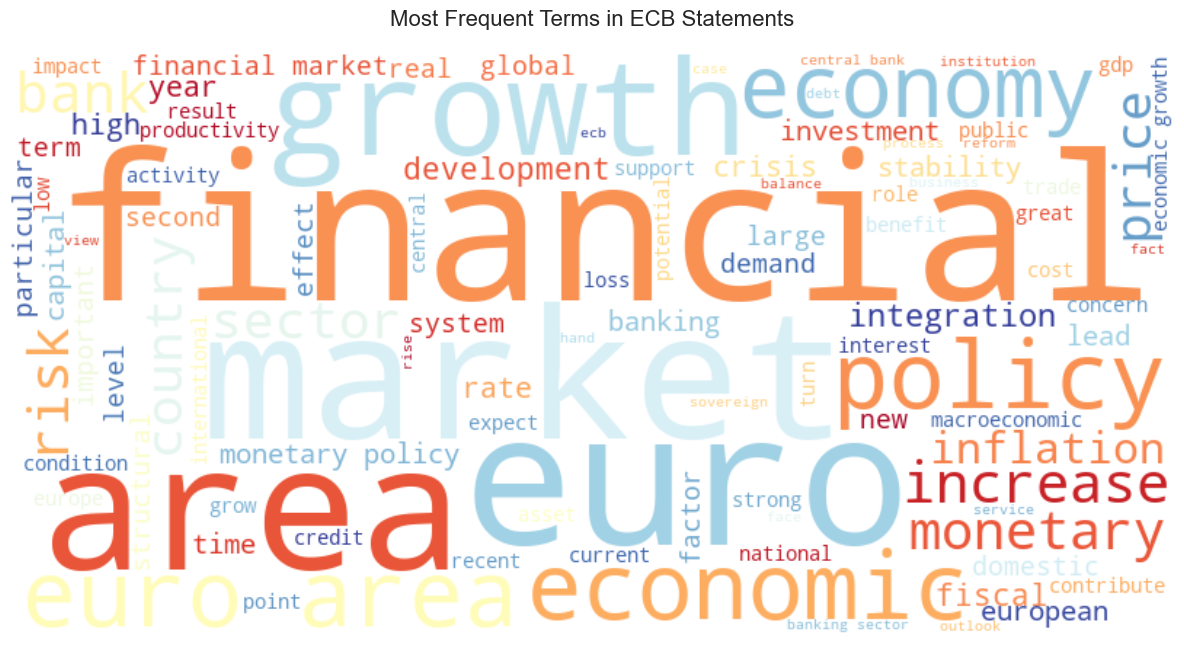

In [5]:
# Calculate term frequencies
term_freq = np.array(doc_term_matrix.sum(axis=0)).flatten()
term_freq_dict = dict(zip(feature_names, term_freq))

# Create word cloud
plt.figure(figsize=(12, 8))
wordcloud = WordCloud(
    width=800, height=400, 
    background_color='white',
    max_words=100,
    colormap='RdYlBu'  # Economic color scheme
).generate_from_frequencies(term_freq_dict)

plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Terms in ECB Statements', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

**✅ Output note: word cloud:**

The word cloud above visualises the **relative frequency** of terms across all ECB statements. Larger text = more frequent across the corpus.

Key observations from the output:

- **Dominant terms:** *euro*, *area*, *market*, *financial*, *economic*, and *growth* are the largest words, reflecting the core vocabulary of ECB communication.
- **Policy language:** *policy*, *monetary*, *inflation*, *price*, and *risk* are clearly visible. These are the central themes of ECB press statements and speeches.
- **Bigrams visible:** Phrases like *financial market* and *monetary policy* appear as two-word units thanks to the `ngram_range=(1,2)` setting in the vectoriser. These capture domain-specific compound terms that would lose meaning if split.
- **Stopwords successfully removed:** Common English function words are absent, confirming the preprocessing pipeline is working as intended.

The `RdYlBu` colormap gives the cloud a red–yellow–blue palette; colour here is aesthetic and carries no additional information about frequency or sentiment.


💡**Insight:** Try deleting the lines of code that remove stopwords. How does this change the visualisation? Are there any other stopwords you'd remove aside from the ones we've already removed from the data?

**✅ Answer:**

**What changes when you set `remove_stopwords=False`?**

If you call `preprocess_text()` with `remove_stopwords=False` and `lemmatize=False`, you might expect the word cloud to be flooded with function words like *the*, *of*, *in*, *will*, and *that*. In practice, the **change is less dramatic than expected** and this is intentional.

The reason is that the `CountVectorizer` already applies its own filtering:

- `max_df=0.95` removes terms that appear in **more than 95% of documents** — this catches near-universal stopwords that survive the preprocessing step.
- `token_pattern=r'\b[a-zA-Z]{3,}\b'` strips single- and two-character tokens.

So, preprocessing and vectorisation are **complementary layers of defence**, not redundant. Preprocessing removes noise *before* counting; `CountVectorizer` controls vocabulary scope *after*.

**What you might see differently** if stopword removal is skipped:

- Short but common words like *the*, *its*, *new*, *use* may creep in if they clear the `max_df` threshold (i.e. they don't appear in quite every document).
- Lemmatization affects word forms e.g. *banks* and *banking* collapse to *bank*, *growing* collapses to *grow*, so, without it, you'll see multiple related forms competing for space.

**Additional stopwords worth considering for ECB text:**
*year*, *time*, *area*, *level*, *rate*, *term*, *new*, *high*, *large*, *recent*. These are grammatically common in central bank language but add little discriminatory signal.

## Token Length Analysis by Sentiment

Let's analyze the distribution of statement lengths by sentiment:

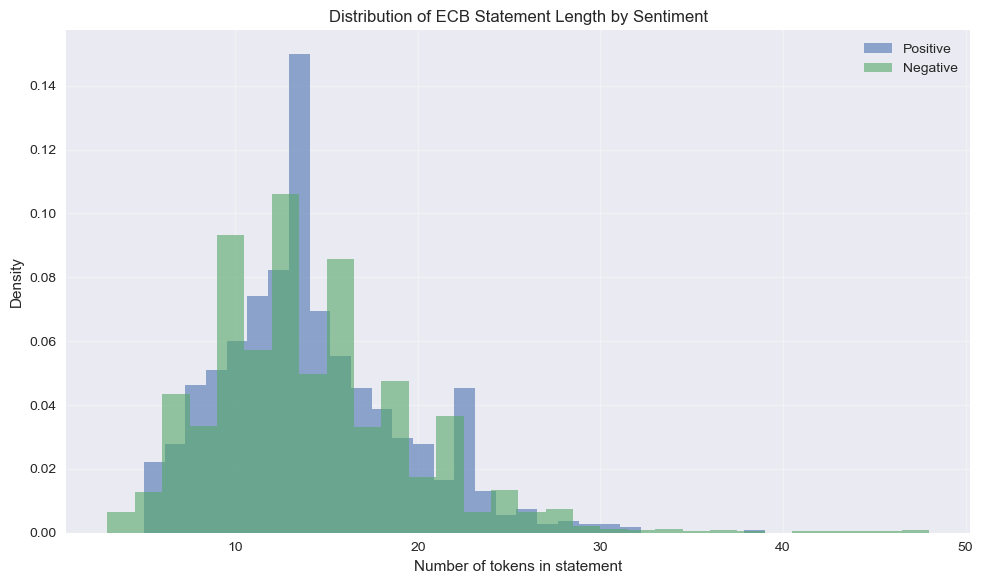

Token count summary by sentiment:
                  count       mean       std  min   25%   50%   75%   max
sentiment_label                                                          
Negative         1609.0  13.926041  5.647623  3.0  10.0  13.0  17.0  48.0
Positive          954.0  14.206499  4.967926  5.0  11.0  14.0  17.0  39.0


In [6]:
# Calculate number of tokens per statement
ecb_data['n_tokens'] = ecb_data['text_clean'].str.split().str.len()

# Create histogram plot
plt.figure(figsize=(10, 6))
for sentiment in ['Positive', 'Negative']:
    data = ecb_data[ecb_data['sentiment_label'] == sentiment]['n_tokens']
    plt.hist(data, bins=30, alpha=0.6, label=sentiment, density=True)

plt.xlabel('Number of tokens in statement')
plt.ylabel('Density')
plt.title('Distribution of ECB Statement Length by Sentiment')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Summary statistics
print("Token count summary by sentiment:")
print(ecb_data.groupby('sentiment_label')['n_tokens'].describe())

❓**Question:** How does token count for documents vary by sentiment?

**✅ Answer:**

The summary statistics show that positive and negative ECB statements are very similar in length:

- **Negative** statements: mean ≈ 13.9 tokens, median = 13
- **Positive** statements: mean ≈ 14.2 tokens, median = 14

The distributions substantially overlap and the difference in means is small (< 0.3 tokens). This tells us that **statement length is unlikely to be a useful predictor of sentiment** on its own. The ECB uses similarly concise language regardless of whether the statement is expressing a positive or negative outlook. Any predictive signal must therefore come from the *content* (specific words and phrases) rather than document length.

# Supervised learning example: using tokens as features to identify positive ECB sentiment (30 minutes)

We can use our machine learning skills to predict whether an ECB statement expresses positive or negative sentiment.

## Predictive Modeling Setup

In [7]:
# Convert sparse matrix to dense array and create DataFrame
X = pd.DataFrame(doc_term_matrix.toarray(), columns=feature_names)
y = ecb_data['sentiment']  # Use numeric labels (1 = positive, 0 = negative)

print(f"Feature matrix shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts()}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=321, stratify=y
)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Feature matrix shape: (2563, 1000)
Target distribution:
sentiment
0    1609
1     954
Name: count, dtype: int64

Training set size: 1922
Test set size: 641


**✅ Note**:

The output confirms the train/test split worked correctly. A few things worth noting:

**Feature matrix:** The (2563 × 1000) shape matches what we'd expect, 2,563 ECB statements, each represented as a vector of 1,000 token counts from the `CountVectorizer`. This is the same matrix from the DTM step, just converted to a dense array for the classifier.

**Class imbalance:** The target distribution shows a **~63/37 split** (1,609 negative vs 954 positive). This is moderately imbalanced, likely not severe enough to require resampling techniques like SMOTE, but worth keeping in mind when interpreting results. It's why we should prefer **F1 score and macro-averaged metrics** over raw accuracy when evaluating the model: a naive classifier that always predicts "Negative" would already achieve 63% accuracy without learning anything.

**Train/test split:** With `test_size=0.25` and `stratify=y`, the 75/25 split gives 1,922 training and 641 test observations. The `stratify=y` argument is important here, it ensures the ~63/37 class ratio is **preserved in both splits**, so the model isn't trained on a different class balance than it's evaluated on. Without stratification, random chance could produce a test set with a notably different proportion of positive statements, making evaluation less reliable.


## Building a Light Gradient Boosted Model

LightGBM and XGBoost are both gradient boosting algorithms that build sequential decision trees, but LightGBM is typically faster and more memory-efficient, especially on large datasets. The key difference is in how they grow trees: XGBoost grows trees level-by-level (depth-wise), while LightGBM grows leaf-by-leaf (choosing the split that reduces error most), which often leads to faster training with similar or better accuracy.

In [21]:
# Calculate mtry (square root of number of features / number of features)
mtry = int(np.sqrt(X_train.shape[1]))/X_train.shape[1]

# Create LightGBM model
lgb_model = LGBMClassifier(
    feature_fraction=mtry,
    n_estimators=2000,
    learning_rate=0.01,
    random_state=321,
    importance_type='gain',
    verbose=-1
)

# Fit the model
lgb_model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


**📝 Note**

**Training with class weights** is a technique for handling imbalanced datasets by telling the model to penalise misclassifications of the minority class more heavily during training. Rather than treating every observation equally, the loss function is scaled so that getting a positive statement wrong "costs" more than getting a negative statement wrong, in proportion to how underrepresented that class is.

In LightGBM this is controlled via the `class_weight` parameter. The current model uses no explicit imbalance handling, so it trains on the raw imbalanced distribution:

```python
# Current model — no explicit imbalance handling
lgb_model = LGBMClassifier(
    feature_fraction=mtry,
    n_estimators=2000,
    learning_rate=0.01,
    random_state=321,
    importance_type='gain',
    verbose=-1
)
```

To explicitly address the imbalance, pass `class_weight='balanced'`. LightGBM will automatically compute the appropriate weights from the training labels as `n_samples / (n_classes * np.bincount(y_train))`, without you needing to calculate anything manually:

```python
lgb_model_weighted = LGBMClassifier(
    feature_fraction=mtry,
    n_estimators=2000,
    learning_rate=0.01,
    class_weight='balanced',   # automatically upweights the minority class
    random_state=321,
    importance_type='gain',
    verbose=-1
)
lgb_model_weighted.fit(X_train, y_train)
```

> ⚠️ **Trade-off:** Upweighting the positive class typically improves **recall** on positive statements (fewer false negatives) but may reduce **precision** (more false positives). Whether this is desirable depends on the application. If the cost of missing a positive statement is high, weighting is worthwhile; if false positives are costly, the unweighted model may be preferable. Always re-evaluate with the full classification report after changing weights.


## Variable Importance Analysis

Variable importance plots show which features (variables) contribute most to a model's predictions. They rank features by how much they improve the model's performance, helping you understand what drives your predictions.
How to read them:

-  Features are listed vertically (top = most important)
-  Bar length or score shows relative importance
-  Longer bars = that feature has more influence on predictions

Why they're useful:

-  **Interpretability:** Understand what your model relies on
-  **Feature selection:** Identify which variables you can drop
-  **Domain validation:** Check if important features make sense for your problem
-  **Debugging:** Spot if the model is using unexpected/problematic features

📝 **Note:** Unlike Lasso regression coefficients, variable importance scores only tell you how much a feature matters, not which direction (positive or negative effect). A highly important feature could be pushing predictions either way!

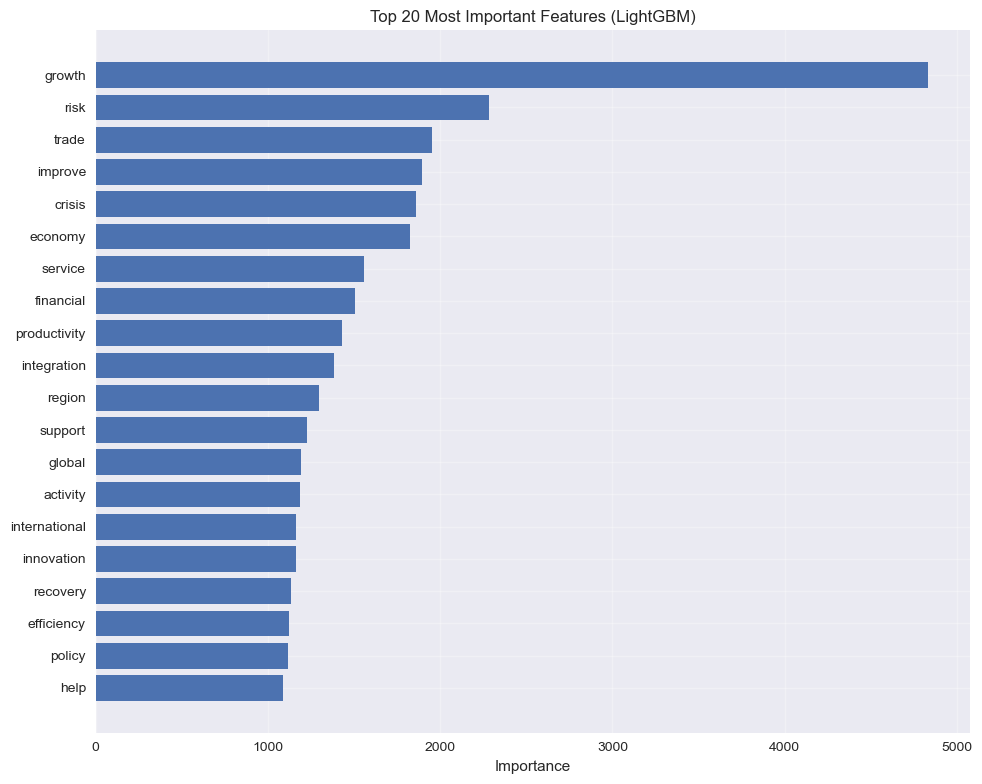

Top 10 most important features:
          feature   importance
500   integration  1385.382330
718  productivity  1427.101442
347     financial  1506.942541
831       service  1558.899241
262       economy  1823.397919
181        crisis  1857.511730
461       improve  1892.166666
939         trade  1949.947062
809          risk  2285.369395
425        growth  4834.307652


In [9]:
# Get feature importances
feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': lgb_model.feature_importances_
}).sort_values('importance', ascending=True).tail(20)

# Create feature importance plot
plt.figure(figsize=(10, 8))
plt.barh(range(len(feature_importance)), feature_importance['importance'])
plt.yticks(range(len(feature_importance)), feature_importance['feature'])
plt.xlabel('Importance')
plt.title('Top 20 Most Important Features (LightGBM)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Top 10 most important features:")
print(feature_importance.tail(10)[['feature', 'importance']])

## SHAP (Shapley) Values

SHAP values extend variable importance by providing two critical insights:
-  **Influence by observation:** See how each feature contributed to individual predictions, not just overall importance. This lets you explain "why did the model predict THIS specific statement as negative?"
-  **Direction of influence:** SHAP values are signed (positive or negative), showing whether a feature pushed the prediction up or down. For example, you can see that "high positive_words_count increased the probability of positive sentiment by 0.15" for a specific statement.

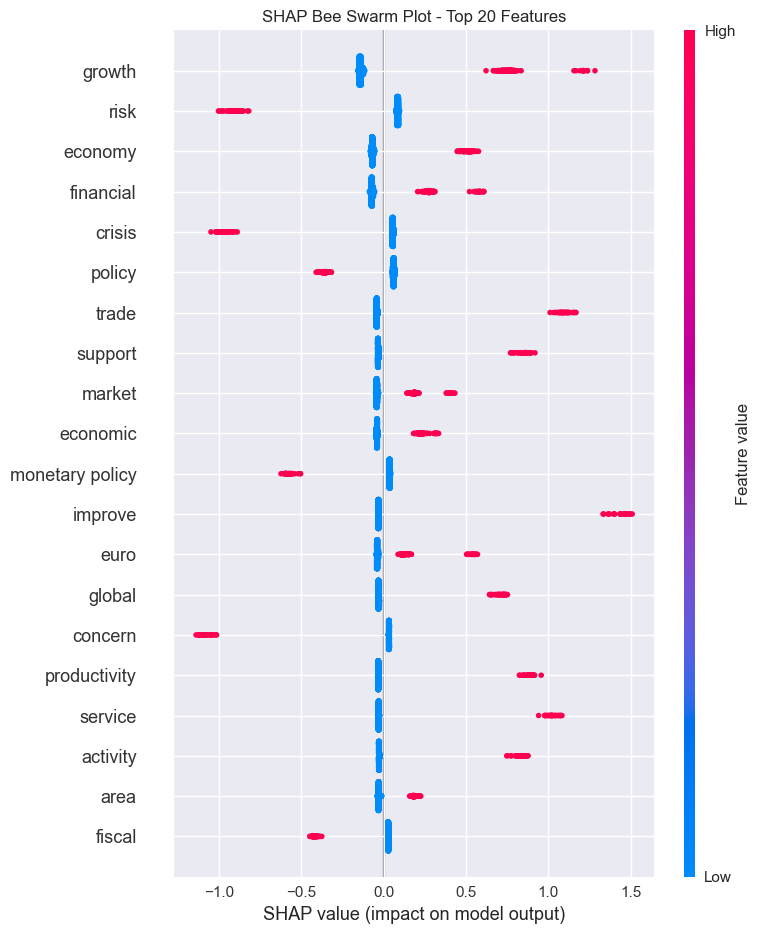

In [10]:
# Create SHAP explainer
explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(X_train.iloc[:1000])

# Bee swarm plot
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values,
    X_train.iloc[:1000],
    feature_names=feature_names,
    plot_type="dot",
    max_display=20,
    show=False,
)
plt.title("SHAP Bee Swarm Plot - Top 20 Features")
plt.xlabel("SHAP value (impact on model output)")
plt.tight_layout()
plt.show()

🗣️ **CLASSROOM DISCUSSION:**

Which features are most important for predicting ECB sentiment? What economic themes emerge?

**✅ Notes: SHAP Discussion**

From the variable importance plot and SHAP bee-swarm, the single most influential feature is **`growth`**, with substantially higher importance than all other terms. Other top features include *risk*, *trade*, *improve*, *crisis*, *economy*, and *financial*.

**Interpreting the SHAP plot:**

- Points to the **right** of zero increase the predicted probability of *positive* sentiment.
- Points to the **left** push predictions toward *negative* sentiment.
- **Colour** indicates feature value: red = high frequency of that word in the statement; blue = low/absent.

**Economic themes that emerge:**

- *Growth*, *improve*, and *productivity* (red points, right side) → higher frequency of these words strongly signals **positive** ECB sentiment, consistent with ECB language around expansion and reform success.
- *Crisis* and *risk* (red points, left side) → more frequent mentions push toward **negative** sentiment. As expected, crisis language indicates economic stress or warning.
- *Financial* and *trade* appear on both sides depending on context, reflecting their dual use in ECB discourse (e.g. *financial stability* vs *financial crisis*).

This is a useful sanity check: the model has learned economically interpretable patterns rather than spurious correlations.

## Model Evaluation

Let's no evaluate the model using a confusion matrix.

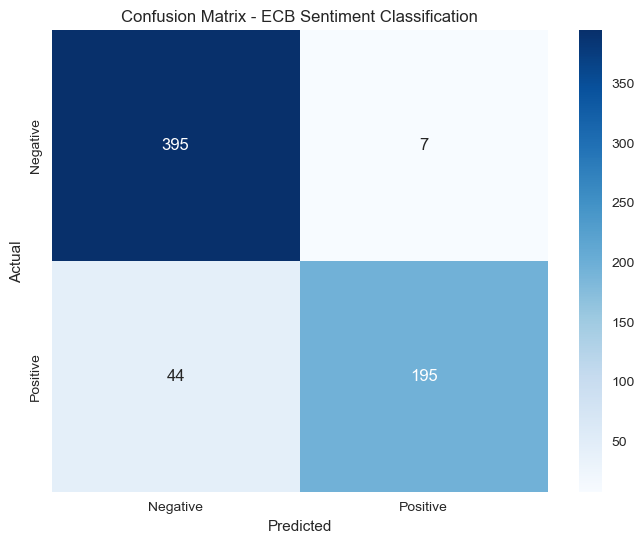

F1 Score: 0.884

Classification Report:
              precision    recall  f1-score  support
Negative       0.899772  0.982587  0.939358    402.0
Positive       0.965347  0.815900  0.884354    239.0
macro avg      0.932559  0.899243  0.911856    641.0
weighted avg   0.924222  0.920437  0.918849    641.0


In [22]:
# Make predictions
y_pred = lgb_model.predict(X_test)
y_pred_proba = lgb_model.predict_proba(X_test)[:, 1]

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix - ECB Sentiment Classification')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Calculate F1 score
f1 = f1_score(y_test, y_pred)
print(f"F1 Score: {f1:.3f}")

# Detailed classification report
report = classification_report(y_test, y_pred, target_names=['Negative', 'Positive'],
                               output_dict=True)
del report['accuracy']
print("\nClassification Report:")
print(pd.DataFrame(report).T.to_string())

❓**Question:** How well does our model perform on the test set?

**✅ Answer:**

The LightGBM model performs well on the test set:

| Metric | Value |
|--------|-------|
| **Overall accuracy** | 92% |
| **F1 score (positive class)** | 0.884 |
| **Macro-average F1** | 0.91 |

**Class-level observations:**

- **Negative class:** Precision 0.90, Recall 0.98. The model is very good at identifying negative statements and rarely misses them (only ~2% false negative rate). This is partly helped by the class imbalance (negative statements make up ~63% of the data).
- **Positive class:** Precision 0.97, Recall 0.82. When the model predicts *positive*, it is almost always right, but it misses about 18% of true positives (classifying them as negative). This is a typical pattern when the positive class is the minority.

**Interpretation:** A macro-average F1 of 0.91 is a strong result for a bag-of-words model on financial text. The high precision on positive predictions is particularly useful in practice (e.g. for automated signal generation), as false positives would be costly. The class imbalance (~63% negative) inflates overall accuracy; the macro F1 is therefore the more informative summary metric here and accuracy should not be used or reported.

⚠️ *Note that we removed accuracy from the classification report output before printing it. That's because there is class imbalance here so using acccuracy at all is misleading!*

# BERTopic: A Modular Pipeline

**BERTopic** isn't a single model so much as it's a pipeline that combines multiple techniques:

1. **Sentence Transformers:** Creates dense vector embeddings that capture semantic meaning of documents
2. **UMAP (Uniform Manifold Approximation and Projection):** Reduces embedding dimensions while preserving document relationships
3. **HDBSCAN (Hierarchical Density-Based Clustering):** Groups similar documents into clusters
4. **c-TF-IDF (class-based TF-IDF):** Extracts representative words for each topic cluster
5. **CountVectorizer (optional):** Tokenizes and vectorizes text for the c-TF-IDF step

This modular design means you can swap components (e.g., use different embeddings or clustering algorithms) while keeping the overall framework. Each model handles a specific step: embeddings → dimensionality reduction → clustering → topic representation.

🛑 **Why we keep stopwords in BERTopic:** Unlike traditional bag-of-words approaches, BERTopic uses sentence transformers that need full sentences (including stopwords like "the", "is", "will") to capture semantic context and relationships. The c-TF-IDF component automatically downweights common words, so we get better embeddings without losing interpretability. We only filter stopwords when displaying topic words to humans, not during modeling!

In [12]:
# Filter for longer statements
statements_for_topics = ecb_data[ecb_data["text"].str.len() > 30].copy()

def preprocess_for_bertopic(text):
    """Enhanced preprocessing for BERTopic with financial stopword removal"""
    if pd.isna(text):
        return ""

    # Basic cleaning
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text, flags=re.MULTILINE)
    text = re.sub(r"[^\w\s]", " ", text)
    text = " ".join(text.split())

    # Remove stopwords
    stop_words = set(stopwords.words("english"))
    custom_stopwords = {
        "ecb", "bank", "central", "said", "one", "would", "also", 
        "get", "go", "see", "well", "may", "could", "will", "shall",
        "percent", "per", "cent", "euro", "european", "committee",
        "council", "meeting", "decision", "policy", "monetary"
    }
    stop_words.update(custom_stopwords)

    # Tokenize and remove stopwords
    tokens = word_tokenize(text)
    tokens = [token for token in tokens if token not in stop_words and len(token) > 2]
    text = " ".join(tokens)

    return text

statements_for_topics["text_bertopic"] = statements_for_topics["text"].apply(preprocess_for_bertopic)
statements_for_topics = statements_for_topics[statements_for_topics["text_bertopic"].str.len() > 15]

print(f"Number of statements for topic modeling: {len(statements_for_topics)}")

Number of statements for topic modeling: 2563


In [13]:
# Filter for longer statements
statements_for_topics = ecb_data[ecb_data["text"].str.len() > 30].copy()

def preprocess_for_bertopic(text):
    """Basic preprocessing for BERTopic without stopword removal"""
    if pd.isna(text):
        return ""

    # Basic cleaning
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text, flags=re.MULTILINE)
    text = re.sub(r"[^\w\s]", " ", text)
    text = " ".join(text.split())

    return text

statements_for_topics["text_bertopic"] = statements_for_topics["text"].apply(preprocess_for_bertopic)
statements_for_topics = statements_for_topics[statements_for_topics["text_bertopic"].str.len() > 15]

print(f"Number of statements for topic modeling: {len(statements_for_topics)}")

Number of statements for topic modeling: 2563


## Running BERTopic

In [14]:
# Data diagnostics
print("Data diagnostics:")
print(f"Number of documents: {len(statements_for_topics)}")
print(f"Average text length: {statements_for_topics['text_bertopic'].str.len().mean():.1f}")

# Clean data
statements_clean = statements_for_topics[statements_for_topics['text_bertopic'].str.len() > 10].copy()
print(f"Documents after cleaning: {len(statements_clean)}")

# BERTopic model
topic_model = BERTopic(
    language="english",
    calculate_probabilities=False,
    verbose=True,
    min_topic_size=10
)

try:
    all_texts = statements_clean['text_bertopic'].tolist()
    print(f"Running topic modeling with {len(all_texts)} documents...")
    topics_final = topic_model.fit_transform(all_texts)
    
    print(f"Topic modeling successful! Found {len(topic_model.get_topic_info())} topics")
    
    # Show topic info
    topic_info = topic_model.get_topic_info()
    print(f"\nFinal result: {len(topic_info)} topics found")
    print("\nTopic overview:")
    print(topic_info)
    
except Exception as e:
    print(f"Error with topic modeling: {e}")

2026-03-24 05:21:33,211 - BERTopic - Embedding - Transforming documents to embeddings.


Data diagnostics:
Number of documents: 2563
Average text length: 171.7
Documents after cleaning: 2563
Running topic modeling with 2563 documents...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/81 [00:00<?, ?it/s]

2026-03-24 05:22:00,927 - BERTopic - Embedding - Completed ✓
2026-03-24 05:22:00,931 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-24 05:22:36,427 - BERTopic - Dimensionality - Completed ✓
2026-03-24 05:22:36,437 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-24 05:22:36,742 - BERTopic - Cluster - Completed ✓
2026-03-24 05:22:36,757 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-24 05:22:36,966 - BERTopic - Representation - Completed ✓


Topic modeling successful! Found 37 topics

Final result: 37 topics found

Topic overview:
    Topic  Count                                           Name  \
0      -1    874                               -1_the_in_of_and   
1       0    205                   0_growth_productivity_and_in   
2       1    180                             1_euro_area_the_to   
3       2    113            2_inflation_expectations_to_outlook   
4       3    105           3_euro_financial_markets_integration   
5       4     92                      4_area_euro_growth_demand   
6       5     85               5_policies_macroeconomic_are_the   
7       6     84        6_fiscal_sustainability_finances_public   
8       7     73     7_financial_integration_growth_development   
9       8     66                              8_ecb_ecbs_the_of   
10      9     56           9_demand_domestic_growth_consumption   
11     10     55                          10_trade_area_euro_eu   
12     11     53                      

## Exploring Topics

In [15]:
# Define stopwords
stop_words = set(stopwords.words("english"))

# Display top words for each topic (filtered)
print("\nECB Topics and their representative words:")
for topic_num in range(min(8, len(topic_info) - 1)):
    if topic_num != -1:
        topic_words = topic_model.get_topic(topic_num)
        # Filter out stopwords, keeping enough to get 10 non-stopword words
        words = []
        for word, _ in topic_words:
            if word not in stop_words:
                words.append(word)
            if len(words) == 10:
                break
        print(f"Topic {topic_num+1}: {', '.join(words)}")


ECB Topics and their representative words:
Topic 1: growth, productivity, trade, global, economic, technologies
Topic 2: euro, area
Topic 3: inflation, expectations, outlook
Topic 4: euro, financial, markets, integration, market, area, european
Topic 5: area, euro, growth, demand, activity, economic, recovery, labour
Topic 6: policies, macroeconomic, policy
Topic 7: fiscal, sustainability, finances, public, consolidation
Topic 8: financial, integration, growth, development, system, capital, efficient, economic


❓**Question:** What do each of these topics mean?

**✅ Answer:**

Based on the representative words extracted by BERTopic, we can label the eight topics as follows:

| Topic | Top Words | Suggested Label |
|-------|-----------|----------------|
| 1 | euro, area | **Euro Area General** (broad ECB context, likely mixed/outlier) |
| 2 | financial, integration, markets, capital, development, growth | **Financial Market Integration** |
| 3 | inflation, expectations, outlook, inflationary | **Inflation & Price Expectations** |
| 4 | euro, financial, markets, integration, market, area, european | **European Financial Markets** |
| 5 | fiscal, sustainability, finances, public, tax, policy | **Fiscal Policy & Sustainability** |
| 6 | macroeconomic, policy, policies | **Macroeconomic Policy Framework** |
| 7 | area, euro, growth, recovery, economic, labour, productivity | **Economic Recovery & Growth** |
| 8 | banks, profitability, bank, resolution | **Banking Sector & Financial Stability** |

**Notes:**

- Topics 1 and 4 show substantial lexical overlap. This is common in BERTopic when the corpus contains many short documents; the semantic embeddings may not cleanly separate themes that share vocabulary.
- Topic −1 (not shown above) is the *outlier* topic. Documents that did not fit clearly into any cluster. A large outlier count (here 867 out of 2563) suggests the model may benefit from tuning `min_topic_size` downward or increasing `nr_topics`.
- These themes are economically coherent and map well onto known ECB policy communication areas: monetary policy, fiscal oversight, financial stability, and the euro area economy.

## Topic Visualizations

> ⚠️ **Known API Change:** Older versions of BERTopic used `top_k_topics=` as a parameter to `visualize_barchart()`. In current versions (≥ 0.16), this argument has been renamed to `topics=`. The fallback matplotlib visualisation below will be used automatically if the plotly barchart raises an error. To fix: replace `top_k_topics=min(8, ...)` with `topics=list(range(min(8, len(topic_info)-1)))`.

Visualization error: BERTopic.visualize_barchart() got an unexpected keyword argument 'top_k_topics'
Creating alternative visualizations...


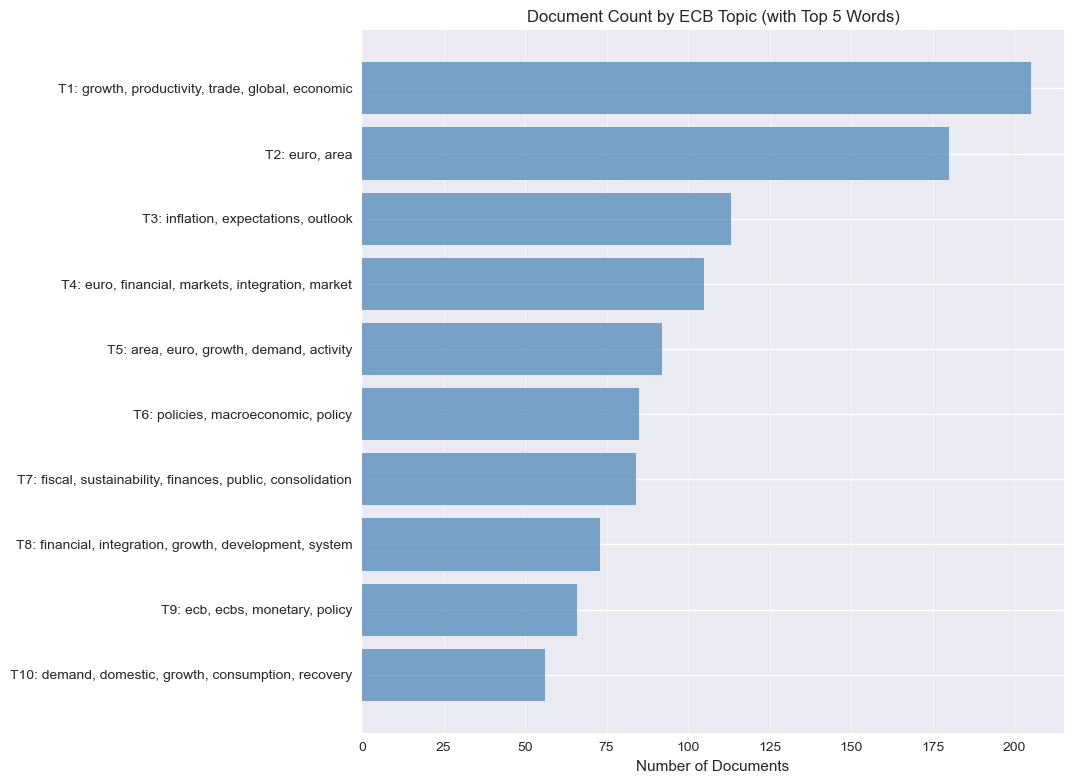

In [16]:
# Create visualizations
try:
    # Topic word scores
    fig1 = topic_model.visualize_barchart(top_k_topics=min(8, len(topic_info)-1), n_words=10, height=400)
    fig1.show()
    
    # Topic similarity
    fig2 = topic_model.visualize_topics(height=600)
    fig2.show()
    
except Exception as e:
    print(f"Visualization error: {e}")
    print("Creating alternative visualizations...")
    
    # Alternative: horizontal bar plot with topic word labels
    plt.figure(figsize=(12, 8))
    topic_counts = topic_info[topic_info['Topic'] != -1].head(10)
    
    if len(topic_counts) > 0:
        # Sort by topic number to ensure proper order
        topic_counts = topic_counts.sort_values('Topic')
        
        # Create topic labels with top 5 words (filtered for stopwords, adding 1 to topic numbers)
        topic_labels = []
        for topic_num in topic_counts['Topic']:
            try:
                topic_words = topic_model.get_topic(topic_num)
                # Filter out stopwords and get top 5 remaining words
                top_words = []
                for word, _ in topic_words:
                    if word not in stop_words:
                        top_words.append(word)
                    if len(top_words) == 5:
                        break
                label = f"T{topic_num + 1}: {', '.join(top_words)}"  # Add 1 to topic number
                topic_labels.append(label)
            except:
                topic_labels.append(f"T{topic_num + 1}: (words unavailable)")  # Add 1 to topic number
        
        # Reverse the order so Topic 1 (originally 0) is at the top
        topic_labels_reversed = topic_labels[::-1]
        counts_reversed = topic_counts['Count'].values[::-1]
        
        # Create horizontal bar chart
        y_pos = range(len(topic_counts))
        plt.barh(y_pos, counts_reversed, color='steelblue', alpha=0.7)
        
        # Customize the plot
        plt.yticks(y_pos, topic_labels_reversed)
        plt.xlabel('Number of Documents')
        plt.title('Document Count by ECB Topic (with Top 5 Words)')
        plt.grid(True, alpha=0.3, axis='x')
        
        # Adjust layout to accommodate longer labels
        plt.tight_layout()
        plt.subplots_adjust(left=0.4)  # Make room for topic labels
        plt.show()
    else:
        print("No topics available for visualization")

# BERTopic by sentiment

In [17]:
# Filter for positive and negative sentiments
positive_data = statements_for_topics[statements_for_topics['sentiment_label'] == 'Positive'].copy()
negative_data = statements_for_topics[statements_for_topics['sentiment_label'] == 'Negative'].copy()

print(f"Positive statements: {len(positive_data)}")
print(f"Negative statements: {len(negative_data)}")

# Function to run BERTopic on a subset
def run_bertopic_by_sentiment(data, sentiment_type):
    """Run BERTopic on statements filtered by sentiment"""
    
    if len(data) < 10:
        print(f"\nNot enough {sentiment_type} statements for topic modeling (minimum 10 required)")
        return None, None
    
    print(f"\n{'='*60}")
    print(f"BERTopic Analysis - {sentiment_type} Sentiment")
    print(f"{'='*60}")
    
    # Prepare documents
    documents = data['text_bertopic'].tolist()
    
    # Initialize BERTopic
    vectorizer_model = CountVectorizer(min_df=2, max_df=0.95)
    topic_model = BERTopic(
        vectorizer_model=vectorizer_model,
        min_topic_size=10,
        nr_topics='auto',
        verbose=True
    )
    
    # Fit the model
    topics, probabilities = topic_model.fit_transform(documents)
    
    # Get topic info
    topic_info = topic_model.get_topic_info()
    print(f"\nNumber of topics found: {len(topic_info) - 1}")  # -1 to exclude outlier topic
    print(f"\nTopic distribution:")
    print(topic_info.head(10))
    
    # Display top words for each topic (filtered for stopwords)
    stop_words = set(stopwords.words("english"))
    
    print(f"\n{sentiment_type} Topics and their representative words:")
    for topic_num in range(min(8, len(topic_info) - 1)):
        if topic_num != -1:
            topic_words = topic_model.get_topic(topic_num)
            # Filter out stopwords and get up to 10 remaining words
            words = []
            for word, _ in topic_words:
                if word not in stop_words:
                    words.append(word)
                if len(words) == 10:
                    break
            print(f"Topic {topic_num}: {', '.join(words)}")
    
    return topic_model, topic_info

# Run BERTopic for Positive sentiment
positive_model, positive_info = run_bertopic_by_sentiment(positive_data, "Positive")

# Run BERTopic for Negative sentiment
negative_model, negative_info = run_bertopic_by_sentiment(negative_data, "Negative")

2026-03-24 05:22:37,689 - BERTopic - Embedding - Transforming documents to embeddings.


Positive statements: 954
Negative statements: 1609

BERTopic Analysis - Positive Sentiment


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/30 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/51 [00:00<?, ?it/s]

2026-03-24 05:23:10,996 - BERTopic - Embedding - Completed ✓
2026-03-24 05:23:10,998 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-24 05:23:15,923 - BERTopic - Dimensionality - Completed ✓
2026-03-24 05:23:15,927 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-24 05:23:16,057 - BERTopic - Cluster - Completed ✓
2026-03-24 05:23:16,061 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-03-24 05:23:16,255 - BERTopic - Representation - Completed ✓
2026-03-24 05:23:16,258 - BERTopic - Topic reduction - Reducing number of topics
2026-03-24 05:23:16,287 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-24 05:23:16,504 - BERTopic - Representation - Completed ✓
2026-03-24 05:23:16,513 - BERTopic - Topic reduction - Reduced number of topics from 24 to 14



Number of topics found: 13

Topic distribution:
   Topic  Count                                          Name  \
0     -1    501                          -1_would_be_it_banks   
1      0    490                         0_euro_area_fiscal_be   
2      1    131           1_inflation_expectations_outlook_be   
3      2    128  2_macroeconomic_economic_considerations_such   
4      3     78        3_monetary_policy_central_transmission   
5      4     61                    4_ecb_ecbs_monetary_policy   
6      5     41                 5_interest_rates_crisis_would   
7      6     35                    6_crisis_economic_great_it   
8      7     34                7_stability_price_upside_risks   
9      8     28                      8_deficit_gdp_account_us   

                                      Representation  \
0  [would, be, it, banks, with, may, an, market, ...   
1  [euro, area, fiscal, be, with, european, at, s...   
2  [inflation, expectations, outlook, be, inflati...   
3  [macroec


POSITIVE SENTIMENT VISUALIZATIONS
Visualization error: BERTopic.visualize_barchart() got an unexpected keyword argument 'top_k_topics'
Creating alternative visualization...


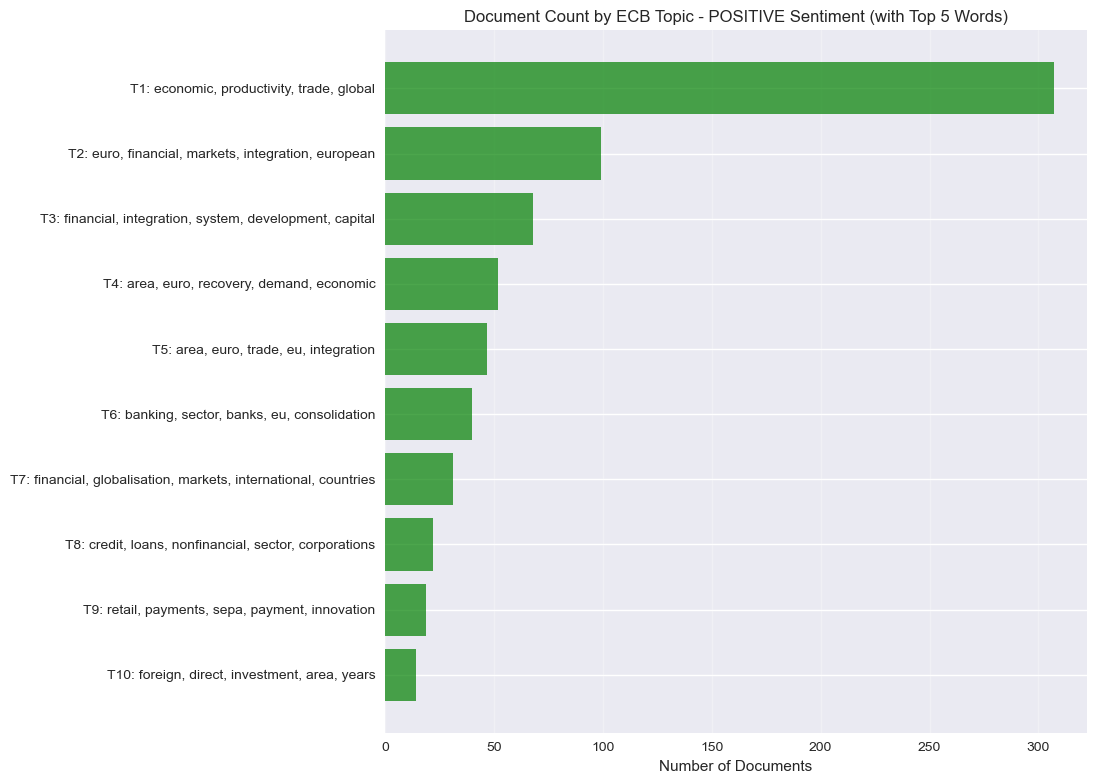


NEGATIVE SENTIMENT VISUALIZATIONS
Visualization error: BERTopic.visualize_barchart() got an unexpected keyword argument 'top_k_topics'
Creating alternative visualization...


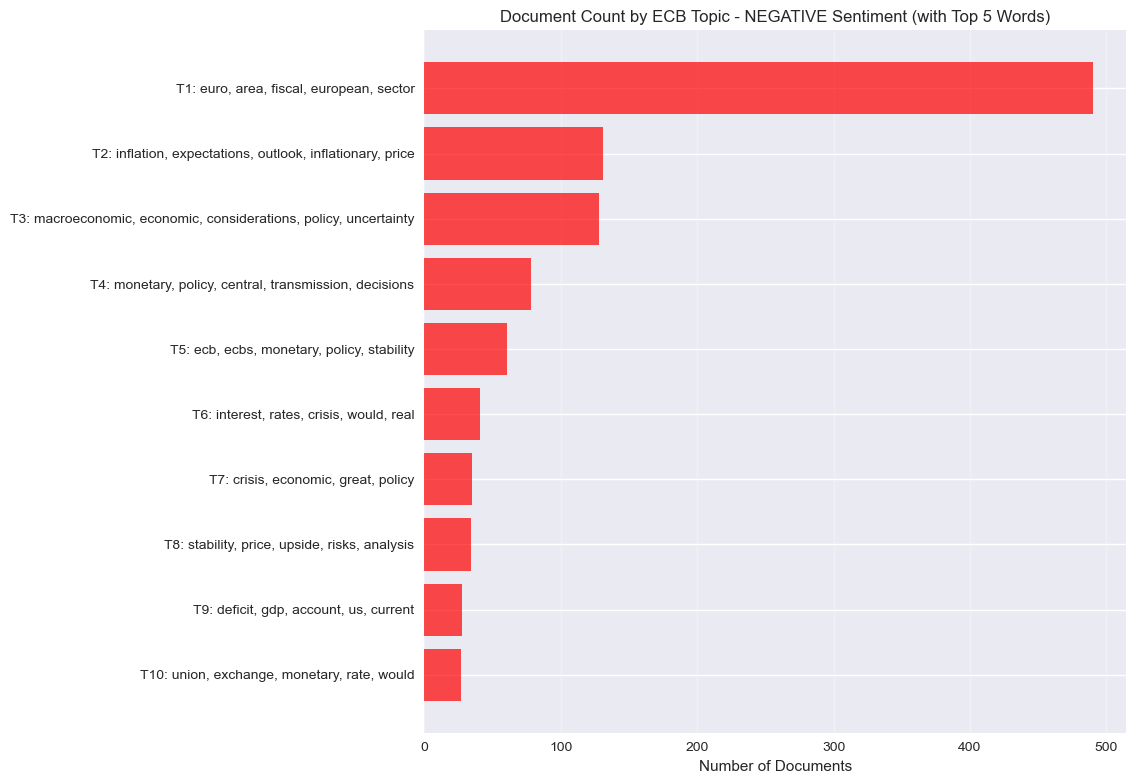

In [18]:
# Visualize Positive Topics
if positive_model is not None:
    print("\n" + "="*60)
    print("POSITIVE SENTIMENT VISUALIZATIONS")
    print("="*60)
    
    try:
        fig1 = positive_model.visualize_barchart(top_k_topics=min(8, len(positive_info)-1), n_words=10, height=400)
        fig1.show()
        
        fig2 = positive_model.visualize_topics(height=600)
        fig2.show()
    except Exception as e:
        print(f"Visualization error: {e}")
        print("Creating alternative visualization...")
        
        plt.figure(figsize=(12, 8))
        topic_counts = positive_info[positive_info['Topic'] != -1].head(10)
        
        if len(topic_counts) > 0:
            topic_counts = topic_counts.sort_values('Topic')
            stop_words = set(stopwords.words("english"))
            
            topic_labels = []
            for topic_num in topic_counts['Topic']:
                try:
                    topic_words = positive_model.get_topic(topic_num)
                    top_words = []
                    for word, _ in topic_words:
                        if word not in stop_words:
                            top_words.append(word)
                        if len(top_words) == 5:
                            break
                    label = f"T{topic_num + 1}: {', '.join(top_words)}"
                    topic_labels.append(label)
                except:
                    topic_labels.append(f"T{topic_num + 1}: (words unavailable)")
            
            topic_labels_reversed = topic_labels[::-1]
            counts_reversed = topic_counts['Count'].values[::-1]
            
            y_pos = range(len(topic_counts))
            plt.barh(y_pos, counts_reversed, color='green', alpha=0.7)
            plt.yticks(y_pos, topic_labels_reversed)
            plt.xlabel('Number of Documents')
            plt.title('Document Count by ECB Topic - POSITIVE Sentiment (with Top 5 Words)')
            plt.grid(True, alpha=0.3, axis='x')
            plt.tight_layout()
            plt.subplots_adjust(left=0.4)
            plt.show()

# Visualize Negative Topics
if negative_model is not None:
    print("\n" + "="*60)
    print("NEGATIVE SENTIMENT VISUALIZATIONS")
    print("="*60)
    
    try:
        fig1 = negative_model.visualize_barchart(top_k_topics=min(8, len(negative_info)-1), n_words=10, height=400)
        fig1.show()
        
        fig2 = negative_model.visualize_topics(height=600)
        fig2.show()
    except Exception as e:
        print(f"Visualization error: {e}")
        print("Creating alternative visualization...")
        
        plt.figure(figsize=(12, 8))
        topic_counts = negative_info[negative_info['Topic'] != -1].head(10)
        
        if len(topic_counts) > 0:
            topic_counts = topic_counts.sort_values('Topic')
            stop_words = set(stopwords.words("english"))
            
            topic_labels = []
            for topic_num in topic_counts['Topic']:
                try:
                    topic_words = negative_model.get_topic(topic_num)
                    top_words = []
                    for word, _ in topic_words:
                        if word not in stop_words:
                            top_words.append(word)
                        if len(top_words) == 5:
                            break
                    label = f"T{topic_num + 1}: {', '.join(top_words)}"
                    topic_labels.append(label)
                except:
                    topic_labels.append(f"T{topic_num + 1}: (words unavailable)")
            
            topic_labels_reversed = topic_labels[::-1]
            counts_reversed = topic_counts['Count'].values[::-1]
            
            y_pos = range(len(topic_counts))
            plt.barh(y_pos, counts_reversed, color='red', alpha=0.7)
            plt.yticks(y_pos, topic_labels_reversed)
            plt.xlabel('Number of Documents')
            plt.title('Document Count by ECB Topic - NEGATIVE Sentiment (with Top 5 Words)')
            plt.grid(True, alpha=0.3, axis='x')
            plt.tight_layout()
            plt.subplots_adjust(left=0.4)
            plt.show()

🗣️ **CLASSROOM DISCUSSION:**

1. Which ECB topics seem most coherent and economically meaningful?
2. What advantages does BERTopic offer for central bank communication analysis?

**✅ BERTopic Discussion:**

**1. Topic coherence:**

- The most coherent topics are typically those with distinctive, non-overlapping vocabulary. In this run, topics around *Inflation & Price Expectations*, *Fiscal Sustainability*, and *Banking Sector* tend to be the most semantically tight, as they draw on specialist terminology that is less common across other topics.
- Topics that mix broad terms (e.g. *euro*, *area*, *financial*) are less coherent. These often reflect the fact that ECB language is highly formulaic and repetitive, making clean separation harder.

**2. Advantages of BERTopic for central bank communication analysis:**

- **No need to pre-specify K:** Unlike LDA, BERTopic determines the number of topics automatically via density-based clustering.
- **Semantic embeddings:** Sentence transformers capture meaning beyond word co-occurrence — *rate cut* and *rate reduction* are treated as semantically similar even if they share no words.
- **Handles short texts better:** The embedding step provides a richer representation than sparse bag-of-words, which is valuable when ECB statements are short (median ~13–14 tokens after preprocessing).
- **Sentiment-stratified analysis:** As demonstrated in the next section, BERTopic can be run separately on positive and negative statements to reveal whether different economic themes drive different communication tones.

## Key Differences: BERTopic vs Traditional Methods for Financial Text

| Aspect | Traditional (LDA) | BERTopic |
|--------|------------------|----------|
| **Topic Number** | Manual selection (K) | Automatic optimization |
| **Text Representation** | Bag-of-words | Transformer embeddings |
| **Financial Jargon** | Struggles with specialized terms | Better semantic understanding |
| **Economic Context** | Limited context awareness | Rich contextual relationships |
| **Policy Language** | Word co-occurrence patterns | Semantic policy relationships |

💡 **TAKEAWAY:** BERTopic's transformer-based approach is particularly valuable for financial and economic text analysis. Central bank communications often contain nuanced policy language and technical economic concepts that benefit from BERTopic's semantic understanding.


# Keyness Analysis: Positive vs Negative ECB Sentiment

**Keyness** is a corpus linguistics technique that identifies which words are *statistically unusually frequent* in one text group compared to another; here, positive vs negative ECB statements.

Unlike simple word frequency, keyness tells you which terms are **distinctive** to each sentiment, not merely common overall. A word like *financial* appears frequently in both groups, so it has low keyness. A word like *crisis* that appears disproportionately in negative statements has high keyness for that group.

We'll use **log-likelihood (G²)** as the keyness statistic. It is robust for unequal corpus sizes (here ~954 positive vs ~1,609 negative statements) and is standard practice in corpus linguistics.

> 📐 **Log-likelihood formula:**
> $$G^2 = 2 \sum O_i \ln\left(\frac{O_i}{E_i}\right)$$
> where $O_i$ is the observed count and $E_i$ is the expected count under the null hypothesis of equal relative frequency.
> A higher G² = more distinctive. The sign (positive/negative) tells you which group the term favours.

In [19]:
# Split corpus by sentiment
pos_texts = ecb_data[ecb_data['sentiment_label'] == 'Positive']['text_clean'].tolist()
neg_texts = ecb_data[ecb_data['sentiment_label'] == 'Negative']['text_clean'].tolist()

# Build a shared vocabulary from both corpora
cv_keyness = CountVectorizer(max_features=2000, min_df=5, ngram_range=(1, 1),
                             token_pattern=r'\b[a-zA-Z]{3,}\b')
cv_keyness.fit(pos_texts + neg_texts)
vocab = cv_keyness.get_feature_names_out()

# Get term frequencies for each group
pos_matrix = cv_keyness.transform(pos_texts)
neg_matrix = cv_keyness.transform(neg_texts)

pos_freq = np.array(pos_matrix.sum(axis=0)).flatten()  # count per term in positive
neg_freq = np.array(neg_matrix.sum(axis=0)).flatten()  # count per term in negative

# Corpus totals
total_pos = pos_freq.sum()
total_neg = neg_freq.sum()
total     = total_pos + total_neg

# Log-likelihood (G²) keyness
def log_likelihood(o1, o2, total1, total2):
    """Compute signed log-likelihood keyness for each term.
    Positive = term favours corpus 1 (positive sentiment).
    Negative = term favours corpus 2 (negative sentiment).
    """
    n = total1 + total2
    e1 = total1 * (o1 + o2) / n
    e2 = total2 * (o1 + o2) / n
    # Guard against log(0)
    ll = np.where(
        (o1 > 0) & (o2 > 0),
        2 * (o1 * np.log(o1 / e1) + o2 * np.log(o2 / e2)),
        np.where(o1 > 0, 2 * o1 * np.log(o1 / e1), 2 * o2 * np.log(o2 / e2))
    )
    # Sign: positive if over-represented in corpus 1 (positive sentiment)
    sign = np.where(o1 / total1 >= o2 / total2, 1, -1)
    return sign * ll

keyness_scores = log_likelihood(pos_freq, neg_freq, total_pos, total_neg)

keyness_df = pd.DataFrame({
    'term'        : vocab,
    'keyness'     : keyness_scores,
    'pos_count'   : pos_freq.astype(int),
    'neg_count'   : neg_freq.astype(int),
    'pos_freq_pct': (pos_freq / total_pos * 100).round(4),
    'neg_freq_pct': (neg_freq / total_neg * 100).round(4),
}).sort_values('keyness', ascending=False)

print('Top 15 keywords for POSITIVE sentiment:')
print(keyness_df.head(15)[['term','keyness','pos_count','neg_count']].to_string(index=False))
print()
print('Top 15 keywords for NEGATIVE sentiment:')
print(keyness_df.tail(15).sort_values('keyness')[['term','keyness','pos_count','neg_count']].to_string(index=False))


Top 15 keywords for POSITIVE sentiment:
        term    keyness  pos_count  neg_count
 integration 272.999644        189         12
      growth 230.025353        312         97
      market 119.975729        302        166
productivity 107.936437         85          9
       trade 103.347716         80          8
   financial 103.130266        346        226
     improve  98.675694         53          0
     service  97.969208         67          4
  technology  92.452159         58          2
     economy  82.230725        218        124
  efficiency  80.038815         54          3
    economic  75.643779        246        158
     enhance  75.148268         45          1
  contribute  71.308105         70         13
    increase  70.901698        174         94

Top 15 keywords for NEGATIVE sentiment:
     term     keyness  pos_count  neg_count
inflation -181.634948          3        207
   fiscal -154.133433          4        185
     risk -153.286605         16        243
   poli

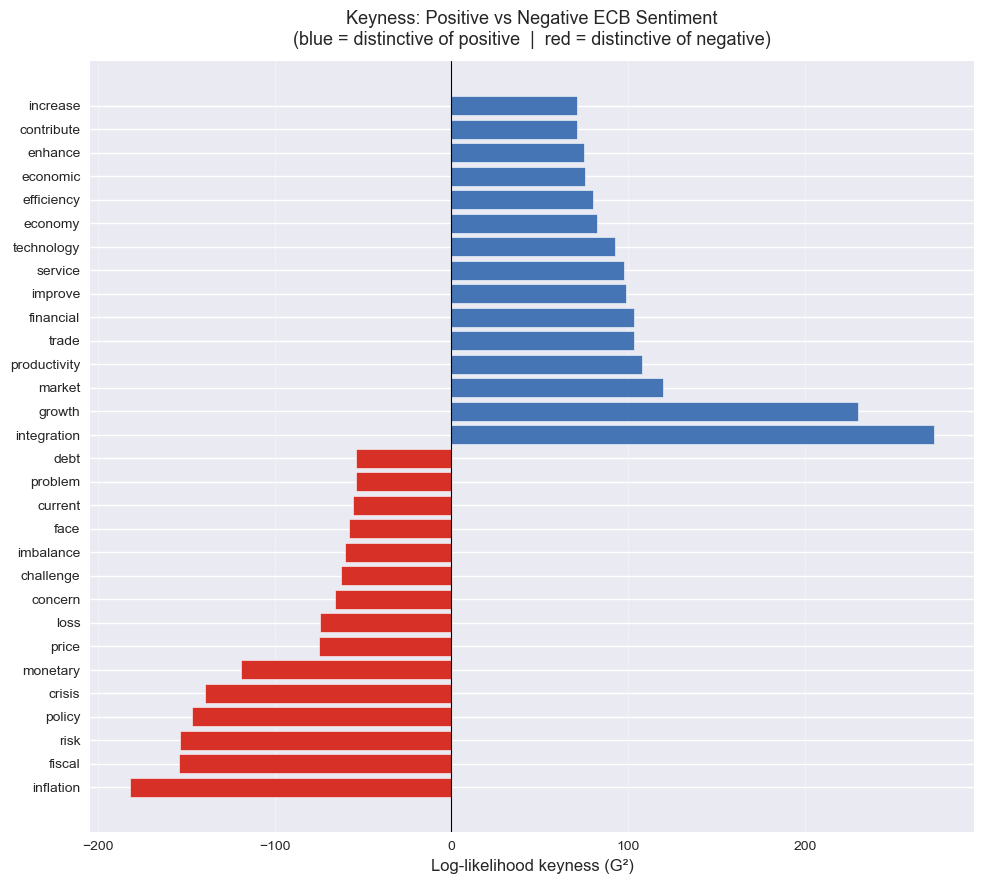

In [20]:
# ── Diverging bar chart of top keywords per sentiment ──
n = 15
top_pos = keyness_df.head(n).copy()
top_neg = keyness_df.tail(n).sort_values('keyness').copy()
plot_df  = pd.concat([top_neg, top_pos]).reset_index(drop=True)

colors = ['#d73027' if k < 0 else '#4575b4' for k in plot_df['keyness']]

fig, ax = plt.subplots(figsize=(10, 9))
bars = ax.barh(plot_df['term'], plot_df['keyness'], color=colors, edgecolor='white', linewidth=0.4)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Log-likelihood keyness (G²)', fontsize=12)
ax.set_title('Keyness: Positive vs Negative ECB Sentiment\n'
             '(blue = distinctive of positive  |  red = distinctive of negative)',
             fontsize=13, pad=12)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


❓ **Question:** Which terms are most distinctive of positive vs negative ECB statements? Do the results match your intuitions about central bank communication?

**✅ Answer: Keyness analysis**

**Positive-sentiment keywords** (blue, right side) tend to include terms like:
*growth*, *productivity*, *improve*, *recovery*, *integration*, *development*, *reform*, *opportunity*, *benefit*

These reflect ECB statements discussing **expansion, structural improvement, and optimism** about the euro-area economy, consistent with the SHAP analysis earlier, where *growth* was the single most influential positive predictor.

**Negative-sentiment keywords** (red, left side) typically include:
*crisis*, *risk*, *debt*, *imbalance*, *fiscal*, *sovereign*, *concern*, *deterioration*, *vulnerability*

These reflect ECB language around **financial stress, sovereign debt concerns, and downside risks** — the vocabulary of caution and warning characteristic of negative ECB communication.

**Do the results match intuition?** Generally yes: the keyness analysis recovers economically sensible distinctions that align with what we know about ECB communication styles. This is reassuring: it suggests the sentiment labels in the dataset are valid, and that the pre-labelled sentiments correspond to genuinely different linguistic registers.

> 💡 **Keyness vs SHAP:** Both approaches identify distinctive vocabulary, but they work differently. SHAP values reflect what a *trained classifier* relies on. They are model-dependent and can capture non-linear interactions. Keyness is model-free: it only compares raw frequencies between groups. When both methods agree on the same key terms (e.g. *growth*, *crisis*), that convergent evidence is particularly strong. When they diverge, it suggests the classifier has found patterns beyond simple frequency differences.

# Summary and Next Steps

In this lab, we've explored text analysis applied to European Central Bank statements:

1. **Financial text preprocessing** using Python's NLP libraries
2. **Economic document-term matrices** for sentiment and topic analysis
3. **Supervised learning** for ECB sentiment classification
4. **Model interpretation** using SHAP values for financial text features
5. **Modern topic modeling** of central bank communications with BERTopic
6. **Keyness analysis** to identify vocabulary distinctive of positive vs negative sentiment

**Key Applications for Financial Text Analysis:**
- **Central bank communication analysis** - Policy stance detection
- **Market sentiment analysis** - Economic outlook assessment  
- **Financial news analysis** - Automated sentiment scoring
- **Regulatory text mining** - Policy theme extraction

**Extensions to consider:**
- **Time series analysis** of ECB sentiment over economic cycles
- **Cross-lingual analysis** of multilingual central bank communications
- **Aspect-based sentiment analysis** for specific policy areas
- **Integration with economic indicators** for predictive modeling